In [2]:
import numpy as np
import matplotlib.pyplot as plt
import opencosmo as oc

/home/eshinbaro/miniconda3/envs/opencosmo_env/lib/python3.11/site-packages/astropy/cosmology/_src/scipy_compat.py:10: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  from scipy.integrate import quad


In [3]:
# Example placeholders — replace with your actual files
halo_file = "haloproperties/m000p-567.haloproperties.hdf5"
gal_file = "galaxyproperties/m000p-567.galaxyproperties.hdf5"

ds = oc.open(halo_file, gal_file, ignore_empty=False)
print(ds)

Collection of halos with galaxy_properties and halo_properties


In [4]:
# Depending on how your data product is structured, you may want to inspect:
print(ds.keys() if hasattr(ds, "keys") else type(ds))

['galaxy_properties', 'halo_properties']


In [12]:
def compute_hod_from_structure_collection(
    ds,
    halo_mass_col="fof_halo_mass",
    mass_min=5e13,
    mass_bins=None,
):
    """
    Compute mean galaxy occupation as a function of halo mass
    from an OpenCosmo structure collection.

    Parameters
    ----------
    ds : OpenCosmo structure collection
        Collection containing halo properties and nested galaxies.
    halo_mass_col : str
        Halo mass column to use.
    mass_min : float
        Minimum halo mass cut.
    mass_bins : array-like or None
        Bin edges in log10(Mhalo). If None, chosen automatically.

    Returns
    -------
    bin_centers : ndarray
    mean_ngal : ndarray
    ngal_std : ndarray
    counts : ndarray
    """
    # Apply halo-level filter first
    ds_filt = ds.filter(oc.col(halo_mass_col) > mass_min)

    halo_masses = []
    ngal_list = []

    for halo in ds_filt.halos():
        halo_props = halo["halo_properties"]

        # halo_props may be dict-like / row-like depending on product
        mhalo = halo_props[halo_mass_col]

        if "galaxy_properties" in halo:
            ngal = len(halo["galaxy_properties"])
        else:
            ngal = 0

        halo_masses.append(mhalo)
        ngal_list.append(ngal)

    halo_masses = np.array([m.to("Msun").value if hasattr(m, "to") else float(m) for m in halo_masses])
    ngal_list = np.asarray(ngal_list, dtype=float)

    logM = np.log10(halo_masses)

    if mass_bins is None:
        mass_bins = np.linspace(logM.min(), logM.max(), 10)

    bin_index = np.digitize(logM, mass_bins) - 1

    bin_centers = 0.5 * (mass_bins[:-1] + mass_bins[1:])
    mean_ngal = np.full(len(bin_centers), np.nan)
    ngal_std = np.full(len(bin_centers), np.nan)
    counts = np.zeros(len(bin_centers), dtype=int)

    for i in range(len(bin_centers)):
        mask = bin_index == i
        counts[i] = mask.sum()
        if counts[i] > 0:
            mean_ngal[i] = ngal_list[mask].mean()
            ngal_std[i] = ngal_list[mask].std()

    return bin_centers, mean_ngal, ngal_std, counts

In [13]:
import astropy.units as u

bin_centers, mean_ngal, ngal_std, counts = compute_hod_from_structure_collection(
    ds,
    halo_mass_col="fof_halo_mass",
    mass_min=5e13 * u.Msun
)

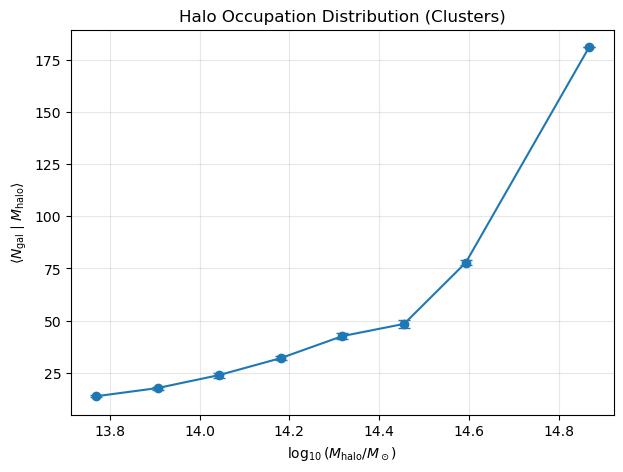

In [15]:
#Plot with error bar 

valid = np.isfinite(mean_ngal)

plt.figure(figsize=(7,5))

plt.errorbar(
    bin_centers[valid],
    mean_ngal[valid],
    yerr=ngal_std[valid] / np.sqrt(counts[valid]),  # ← error bars
    marker='o',
    capsize=4
)

plt.xlabel(r'$\log_{10}(M_{\rm halo}/M_\odot)$')
plt.ylabel(r'$\langle N_{\rm gal} \mid M_{\rm halo} \rangle$')
plt.title('Halo Occupation Distribution (Clusters)')
plt.grid(True, alpha=0.3)

plt.show()